## Day 3 – Exploratory Data Analysis (EDA)

### Objectives

- Perform exploratory data analysis on NAV, AUM, SIP, Folio and Investor datasets
- Create publication-quality visualizations using Matplotlib, Seaborn and Plotly
- Identify key trends, patterns and anomalies
- Generate business insights for mutual fund performance and investor behaviour


In [115]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pathlib import Path

sns.set_style("whitegrid")

charts_dir = Path("../reports/charts")
charts_dir.mkdir(parents=True, exist_ok=True)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [116]:
from pathlib import Path

BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data" / "processed"
CHART_DIR = BASE_DIR / "reports" / "charts"

fund_master = pd.read_csv(DATA_DIR / "01_fund_master_clean.csv")
nav_history = pd.read_csv(DATA_DIR / "02_nav_history_clean.csv")
aum = pd.read_csv(DATA_DIR / "03_aum_clean.csv")
sip = pd.read_csv(DATA_DIR / "04_sip_clean.csv")
category = pd.read_csv(DATA_DIR / "05_category_clean.csv")
folios = pd.read_csv(DATA_DIR / "06_folios_clean.csv")
performance = pd.read_csv(DATA_DIR / "07_performance_clean.csv")
transactions = pd.read_csv(DATA_DIR / "08_transactions_clean.csv")
holdings = pd.read_csv(DATA_DIR / "09_holdings_clean.csv")
benchmark = pd.read_csv(DATA_DIR / "10_benchmark_clean.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [117]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

aum["date"] = pd.to_datetime(aum["date"])

sip["month"] = pd.to_datetime(sip["month"])

category["month"] = pd.to_datetime(category["month"])

folios["month"] = pd.to_datetime(folios["month"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

print("Date conversions completed.")

Date conversions completed.


# 1. NAV Trend Analysis

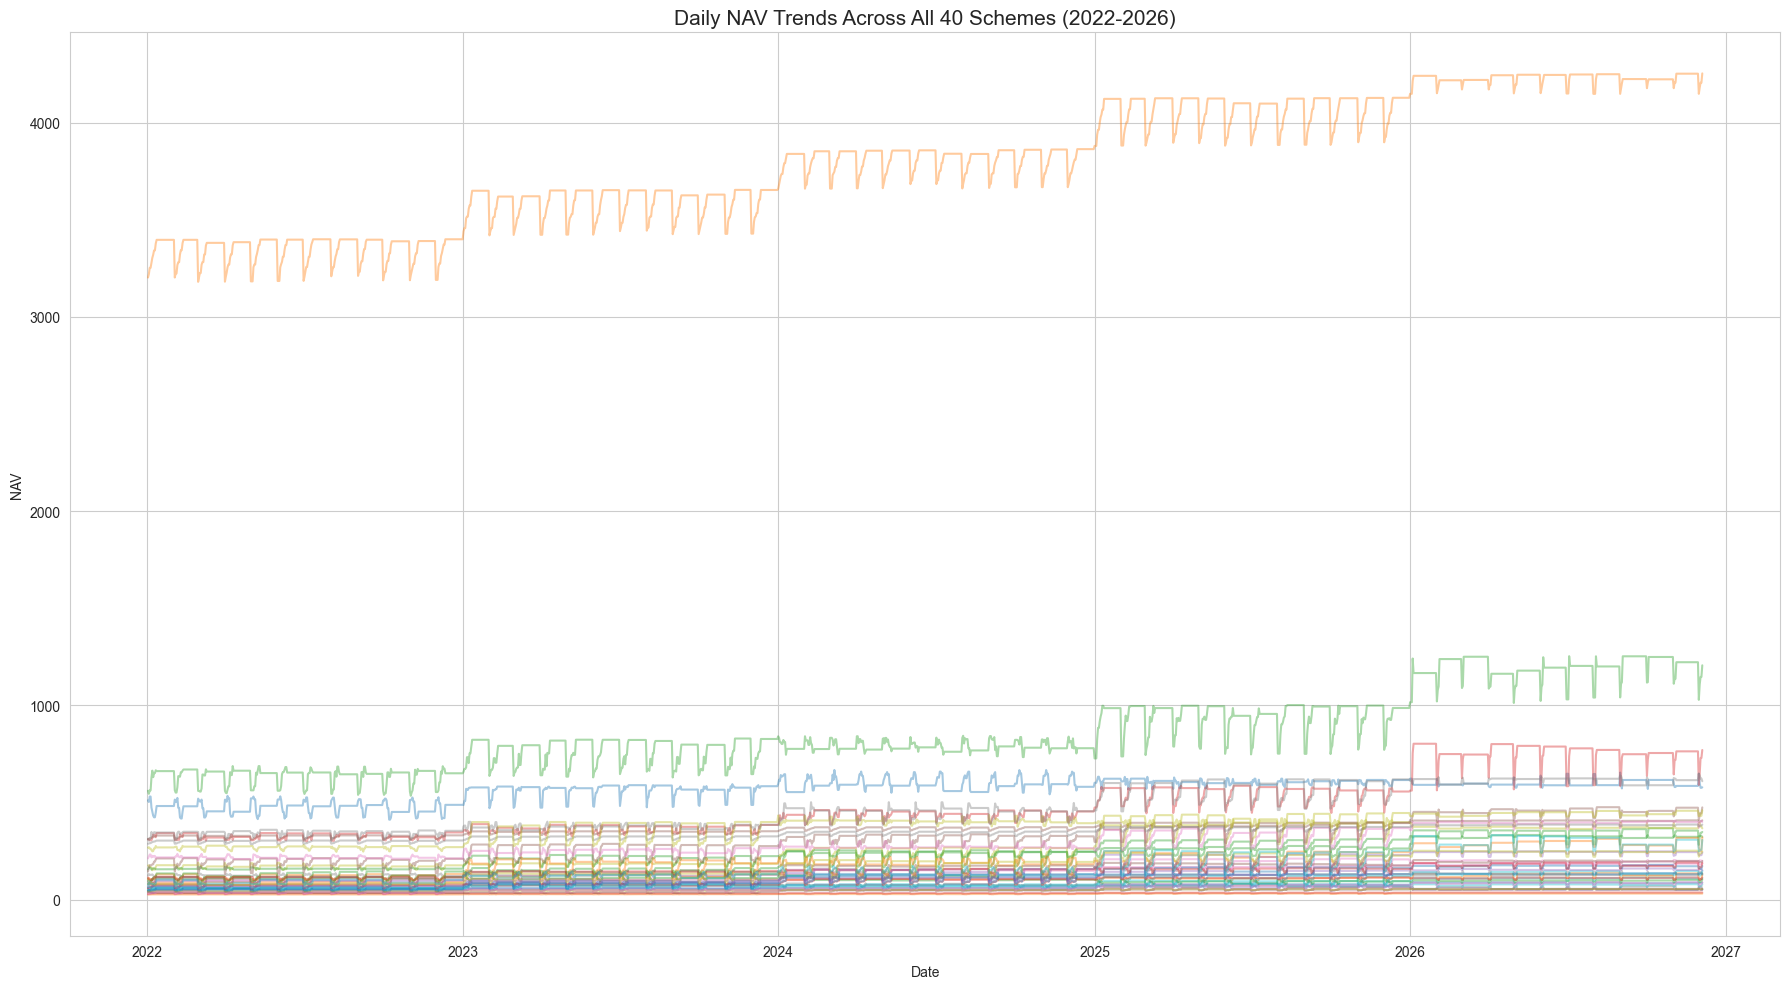

In [80]:
plt.figure(figsize=(18,10))

for scheme in nav_history["amfi_code"].unique():

    temp = nav_history[
        nav_history["amfi_code"] == scheme
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        alpha=0.4
    )

plt.title(
    "Daily NAV Trends Across All 40 Schemes (2022-2026)",
    fontsize=15
)

plt.xlabel("Date")
plt.ylabel("NAV")

plt.tight_layout()

plt.savefig(
    "../reports/charts/01_nav_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [81]:
fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Interactive NAV Trend Analysis"
)

fig.show()

### Average Industry NAV Trend

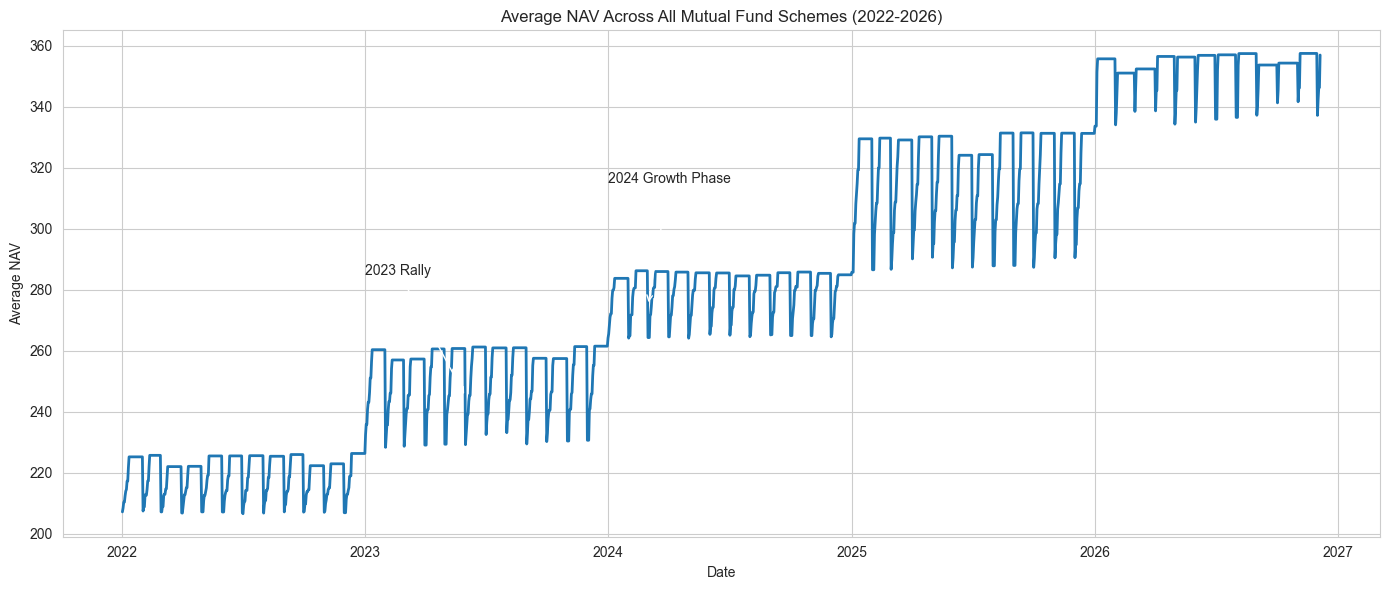

In [82]:
avg_nav = (
    nav_history
    .groupby("date")["nav"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14,6))

plt.plot(
    avg_nav["date"],
    avg_nav["nav"],
    linewidth=2
)

plt.title(
    "Average NAV Across All Mutual Fund Schemes (2022-2026)"
)

plt.xlabel("Date")
plt.ylabel("Average NAV")

plt.annotate(
    "2023 Rally",
    xy=(pd.Timestamp("2023-06-01"), 245),
    xytext=(pd.Timestamp("2023-01-01"), 285),
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    "2024 Growth Phase",
    xy=(pd.Timestamp("2024-03-01"), 275),
    xytext=(pd.Timestamp("2024-01-01"), 315),
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/01b_avg_nav_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [83]:
nav_history["date"].isna().sum()

np.int64(0)

In [84]:
nav_history[
    nav_history["date"].isna()
]["amfi_code"].nunique()

0

In [85]:
nav_history[
    nav_history["date"].isna()
]["amfi_code"].unique()

array([], dtype=int64)

In [86]:
nav_history[
    nav_history["amfi_code"] == 149324
].sort_values("date")

,date,amfi_code,nav
70161,2022-01-02,149324,78.8716
70162,2022-01-03,149324,85.1930
70163,2022-01-04,149324,82.9813
70164,2022-01-05,149324,82.9813
70165,2022-01-06,149324,82.5120
...,...,...,...
71955,2026-12-01,149324,250.1877
71956,2026-12-02,149324,251.3798
71957,2026-12-03,149324,256.9860
71958,2026-12-04,149324,256.9860


In [87]:
clean_nav = nav_history.dropna(subset=["date"]).copy()

clean_nav["return_pct"] = (
    clean_nav
    .sort_values(["amfi_code", "date"])
    .groupby("amfi_code")["nav"]
    .pct_change() * 100
)

clean_nav.nsmallest(
    20,
    "return_pct"
)[["date", "amfi_code", "return_pct"]]

,date,amfi_code,return_pct
71315,2025-03-01,149324,-52.352599
71287,2025-02-01,149324,-50.979706
71407,2025-06-01,149324,-49.234836
71468,2025-08-01,149324,-49.015915
71437,2025-07-01,149324,-48.046654
71499,2025-09-01,149324,-46.761803
71529,2025-10-01,149324,-46.632048
71591,2025-12-02,149324,-41.057838
71561,2025-11-02,149324,-40.986676
62200,2024-11-01,148567,-40.823152


In [88]:
# Create Year column

aum["year"] = aum["date"].dt.year

# Aggregate AUM by Fund House and Year

aum_yearly = (
    aum.groupby(["year", "fund_house"])["aum_crore"]
    .sum()
    .reset_index()
)

aum_yearly.head()

,year,fund_house,aum_crore
0,2022,Aditya Birla Sun Life MF,563000
1,2022,Axis Mutual Fund,490000
2,2022,DSP Mutual Fund,222000
3,2022,HDFC Mutual Fund,880000
4,2022,ICICI Prudential MF,953000


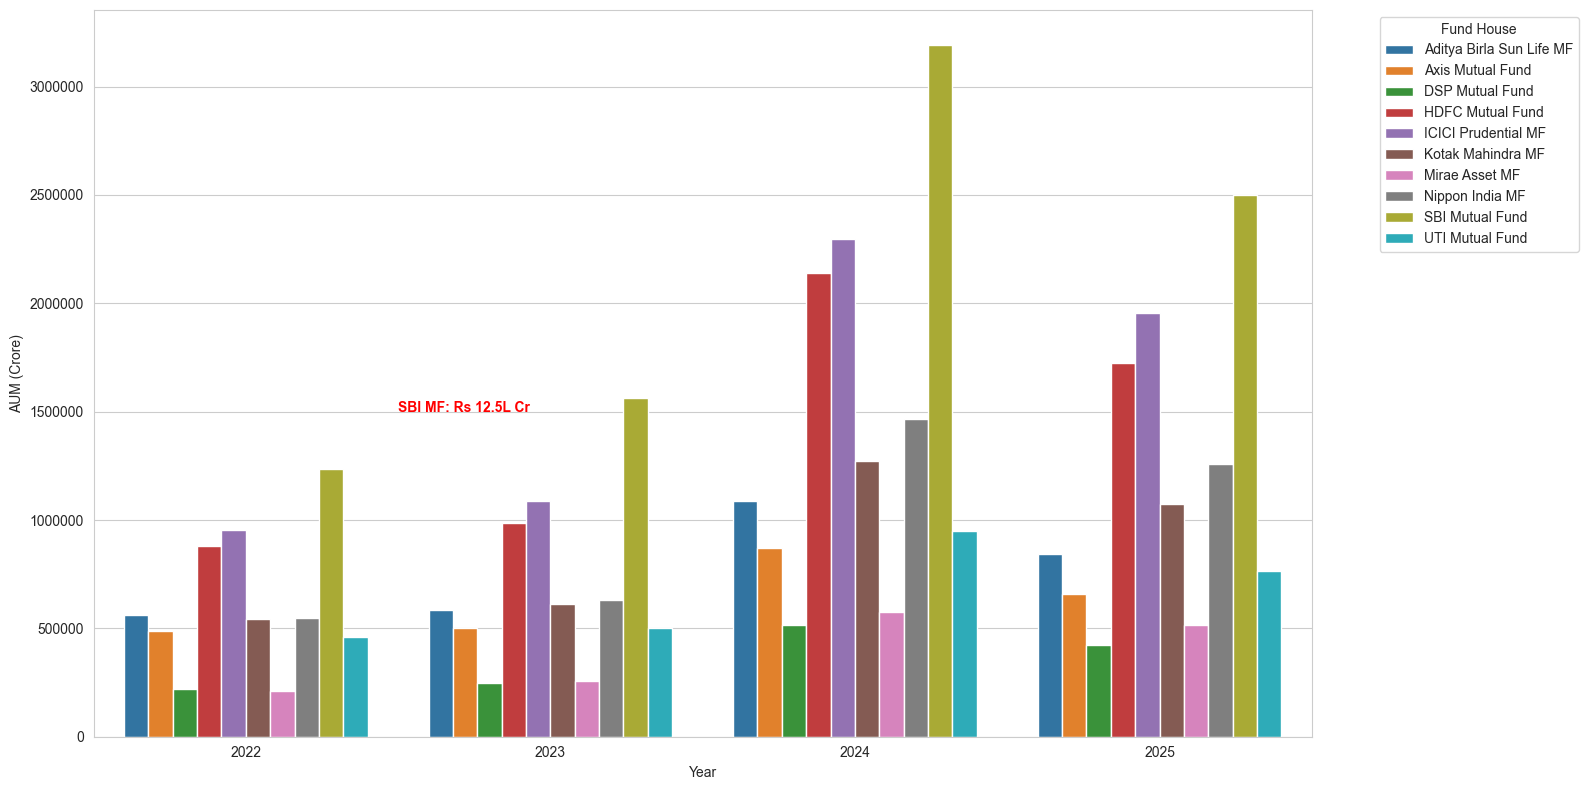

In [89]:
plt.figure(figsize=(16,8))

ax = sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_crore",
    hue="fund_house"
)
plt.annotate(
    "SBI MF: Rs 12.5L Cr",
    xy=(2, 1500000),
    xytext=(0.5, 1500000),
    color="red",
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("AUM (Crore)")

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [90]:
sbi_aum = (
    aum[aum["fund_house"].str.contains("SBI", case=False)]
    ["aum_crore"]
    .max()
)

print("Highest SBI AUM:", round(sbi_aum,2), "Crore")

Highest SBI AUM: 1250000 Crore


In [91]:
print("Years Available:")
print(sorted(aum["year"].unique()))

print()

print("Fund Houses:")
print(aum["fund_house"].nunique())

print()

print("Total Records:")
print(len(aum))

Years Available:
[np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

Fund Houses:
10

Total Records:
90


# 3. SIP Inflow Trend Analysis


In [92]:
sip.head()

print("Records:", len(sip))
print("Date Range:", sip["month"].min(), "to", sip["month"].max())

Records: 48
Date Range: 2022-01-01 00:00:00 to 2025-12-01 00:00:00


In [93]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022-2025)",
    markers=True
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr Milestone",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (Crore ₹)"
)

fig.show()

/var/folders/f7/_gxg7ls978sccd0fgbz58h_80000gn/T/ipykernel_43145/3279440173.py:28: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/f7/_gxg7ls978sccd0fgbz58h_80000gn/T/ipykernel_43145/3279440173.py:30: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


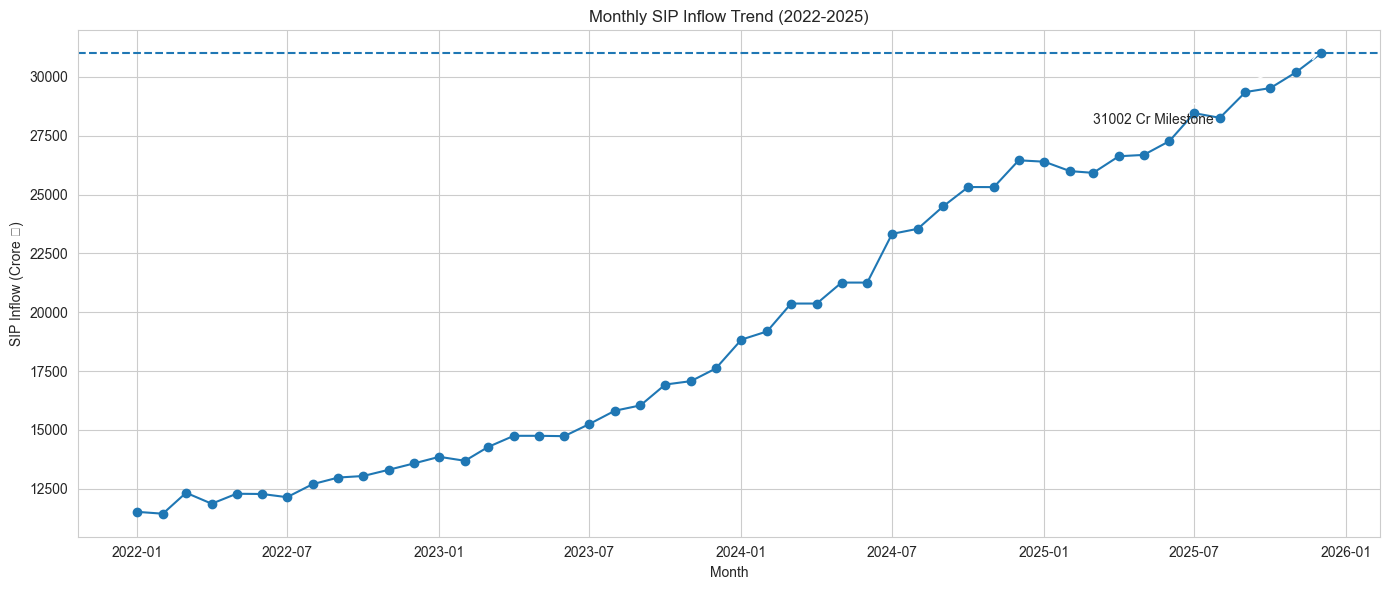

In [94]:
plt.figure(figsize=(14,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.axhline(
    31002,
    linestyle="--"
)

plt.annotate(
    "31002 Cr Milestone",
    xy=(pd.Timestamp("2025-12-01"), 31002),
    xytext=(pd.Timestamp("2025-03-01"), 28000),
    arrowprops=dict(arrowstyle="->")
)

plt.title(
    "Monthly SIP Inflow Trend (2022-2025)"
)

plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore ₹)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/03_sip_inflow_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. Category-wise Inflow Heatmap

In [95]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


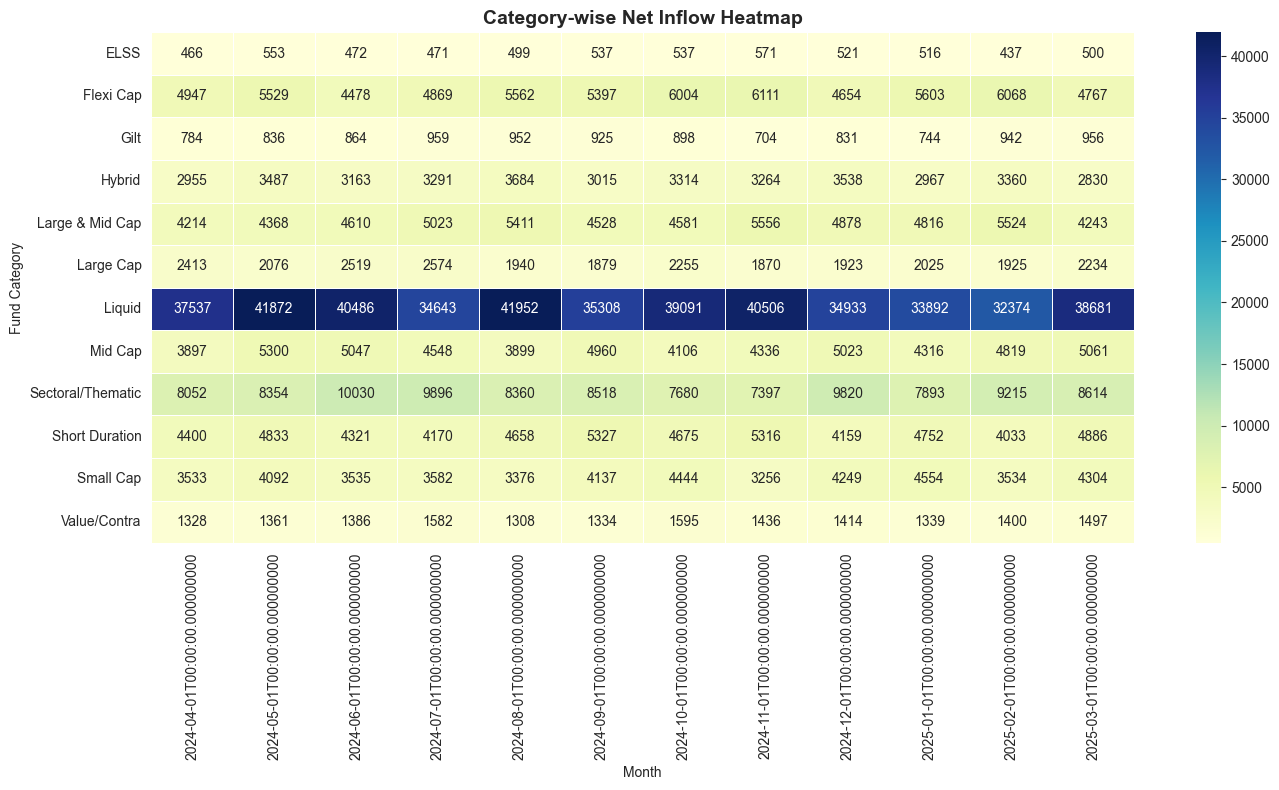

In [96]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title(
    "Category-wise Net Inflow Heatmap",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    "../reports/charts/04_category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

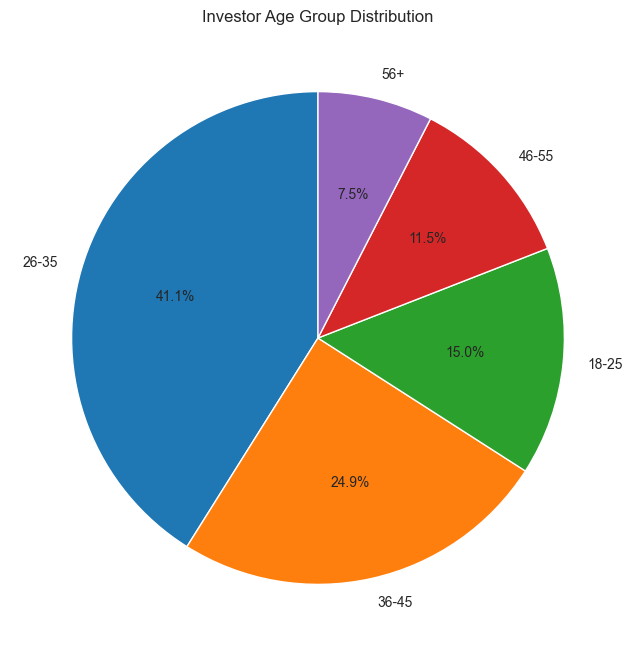

In [97]:
# ============================================================
# 5A. AGE GROUP DISTRIBUTION
# ============================================================

age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/charts/05a_age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/var/folders/f7/_gxg7ls978sccd0fgbz58h_80000gn/T/ipykernel_43145/2124945595.py:17: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


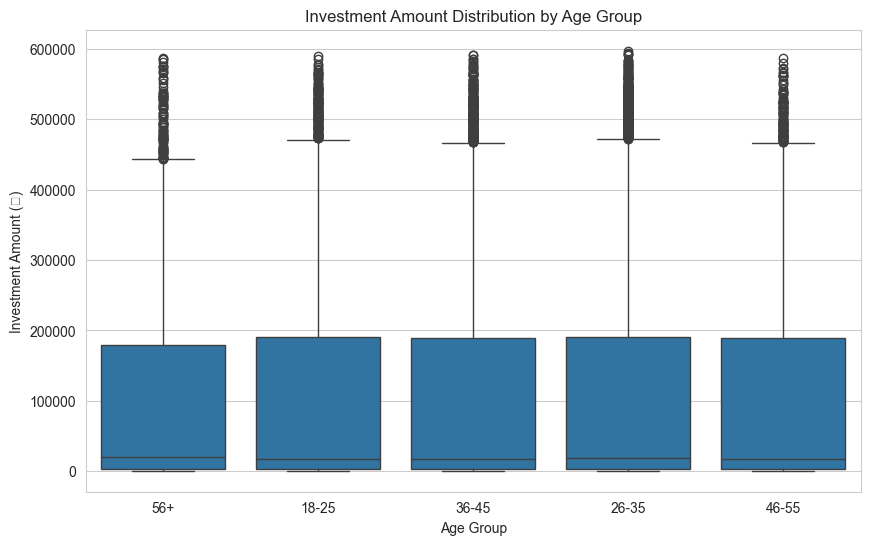

In [98]:
# ============================================================
# 5B. SIP AMOUNT BOXPLOT BY AGE GROUP
# ============================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.savefig(
    "../reports/charts/05b_sip_boxplot_by_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/var/folders/f7/_gxg7ls978sccd0fgbz58h_80000gn/T/ipykernel_43145/1415464998.py:22: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/f7/_gxg7ls978sccd0fgbz58h_80000gn/T/ipykernel_43145/1415464998.py:24: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


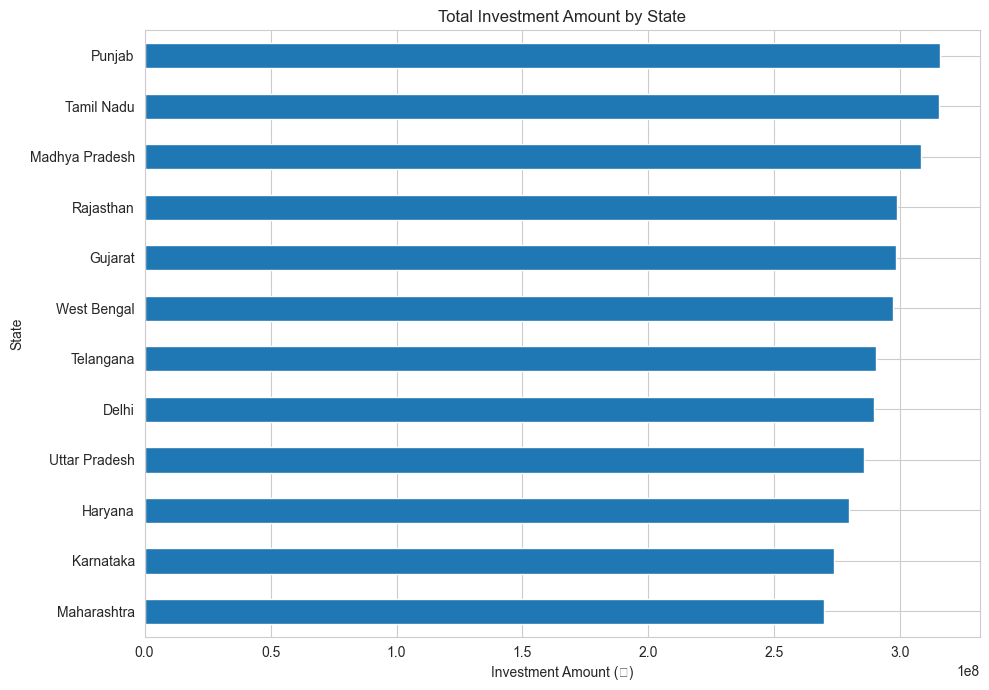

In [99]:
# ============================================================
# 6A. SIP AMOUNT BY STATE
# ============================================================

state_sip = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,7))

state_sip.plot(kind="barh")

plt.gca().invert_yaxis()   

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/charts/06a_state_sip_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

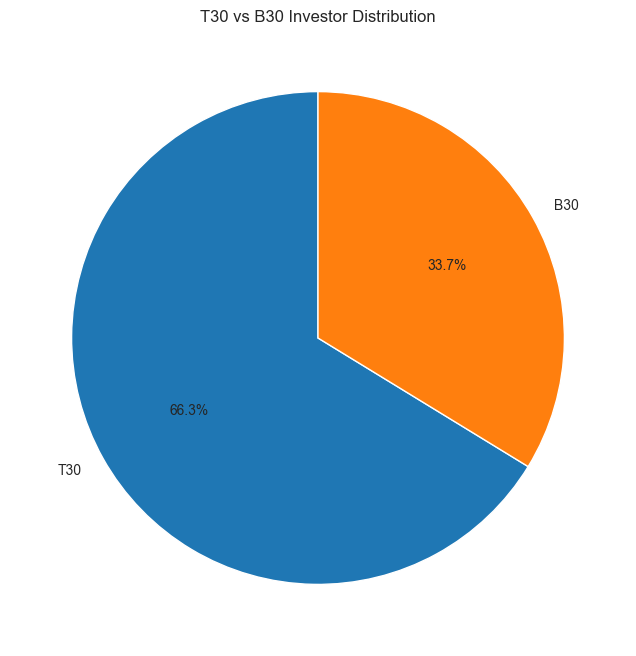

In [100]:
# ============================================================
# 6B. T30 vs B30 DISTRIBUTION
# ============================================================

tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig(
    "../reports/charts/06b_t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [101]:
# ==================================================
# 7. FOLIO COUNT GROWTH
# ==================================================
import plotly.express as px

fig = px.line(
    folios,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Mutual Fund Folio Growth (2022-2025)"
)

fig.add_annotation(
    x=folios.iloc[0]["month"],
    y=folios.iloc[0]["total_folios_crore"],
    text="13.26 Cr",
    showarrow=True
)

fig.add_annotation(
    x=folios.iloc[-1]["month"],
    y=folios.iloc[-1]["total_folios_crore"],
    text="26.12 Cr",
    showarrow=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Folios (Crore)"
)

fig.show()

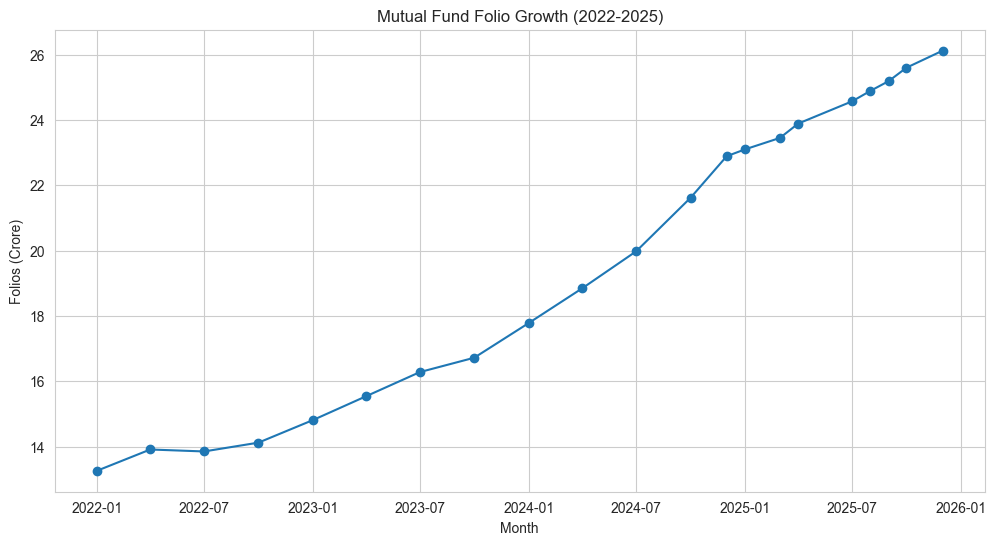

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"],
    marker="o"
)

plt.title("Mutual Fund Folio Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.grid(True)

plt.savefig(
    "../reports/charts/07_folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [103]:
top_10_funds = nav_history["amfi_code"].unique()[:10]
top_10_funds

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632])

In [104]:
nav_10 = nav_history[
    nav_history["amfi_code"].isin(top_10_funds)
].copy()

nav_pivot = nav_10.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

nav_pivot.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-02,512.1124,26.2096,107.8211,310.7970,40.1231,312.8660,92.9079,124.7020,175.9585,45.8044
2022-01-03,503.1674,26.5866,104.6070,311.0737,40.3718,314.8561,89.0402,132.2117,177.3750,47.0303
2022-01-04,531.2850,26.7939,96.4571,305.8097,41.1994,316.4123,85.6037,128.1511,168.2833,50.1618
2022-01-05,531.2850,26.7939,96.4571,305.8097,41.1994,316.4123,85.6037,128.1511,168.2833,50.1618
2022-01-06,474.1732,27.3702,95.1712,306.2298,36.9015,319.8902,94.2402,128.6478,165.9781,53.2522


In [105]:
returns = nav_pivot.pct_change()

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-03,-0.017467,0.014384,-0.029810,0.000890,0.006198,0.006361,-0.041629,0.060221,0.008050,0.026764
2022-01-04,0.055881,0.007797,-0.077910,-0.016922,0.020499,0.004943,-0.038595,-0.030713,-0.051257,0.066585
2022-01-05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-01-06,-0.107497,0.021509,-0.013331,0.001374,-0.104319,0.010992,0.100889,0.003876,-0.013698,0.061609


In [106]:
corr_matrix = returns.corr()

corr_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.013715,-0.041660,-0.033478,-0.095639,0.064032,0.156224,0.022480,0.219464,0.190102
100025,0.013715,1.000000,0.366332,0.437088,0.078977,0.677918,0.470886,-0.393218,0.447695,0.498014
100033,-0.041660,0.366332,1.000000,0.625228,0.182002,0.641629,0.242400,0.034774,0.438201,0.347363
101206,-0.033478,0.437088,0.625228,1.000000,-0.048354,0.646785,0.401240,-0.308796,0.402774,0.497081
101207,-0.095639,0.078977,0.182002,-0.048354,1.000000,0.371277,0.072893,0.256871,0.129645,0.073520
101208,0.064032,0.677918,0.641629,0.646785,0.371277,1.000000,0.650902,-0.176209,0.512091,0.682888
102885,0.156224,0.470886,0.242400,0.401240,0.072893,0.650902,1.000000,-0.337293,0.313972,0.615935
102886,0.022480,-0.393218,0.034774,-0.308796,0.256871,-0.176209,-0.337293,1.000000,-0.060284,-0.271194
102887,0.219464,0.447695,0.438201,0.402774,0.129645,0.512091,0.313972,-0.060284,1.000000,0.206504


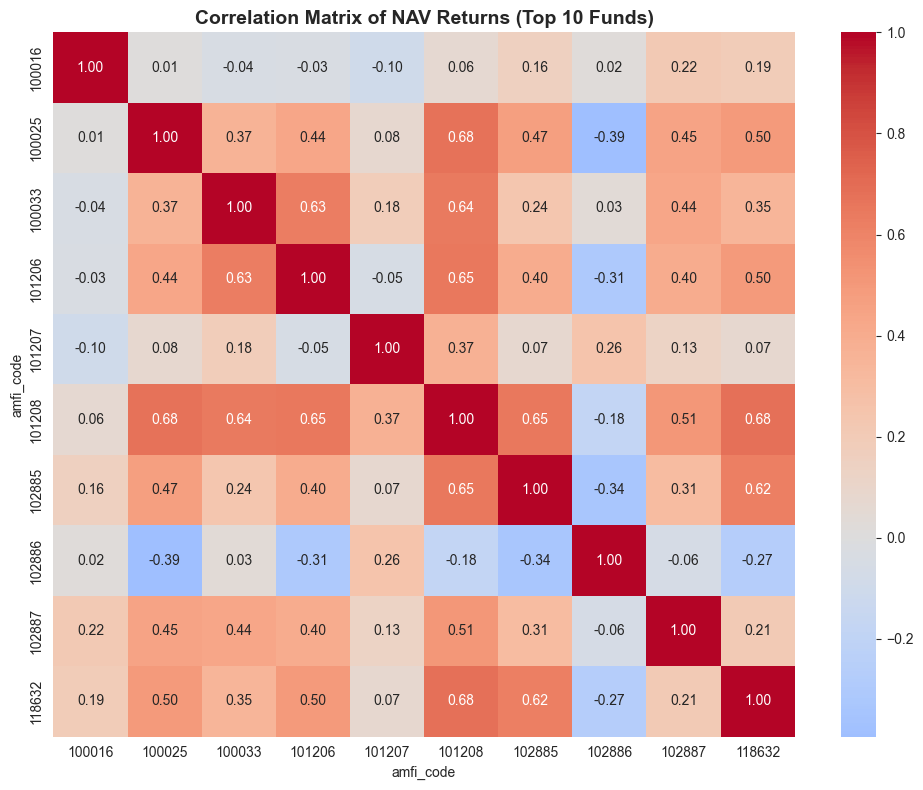

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of NAV Returns (Top 10 Funds)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/08_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

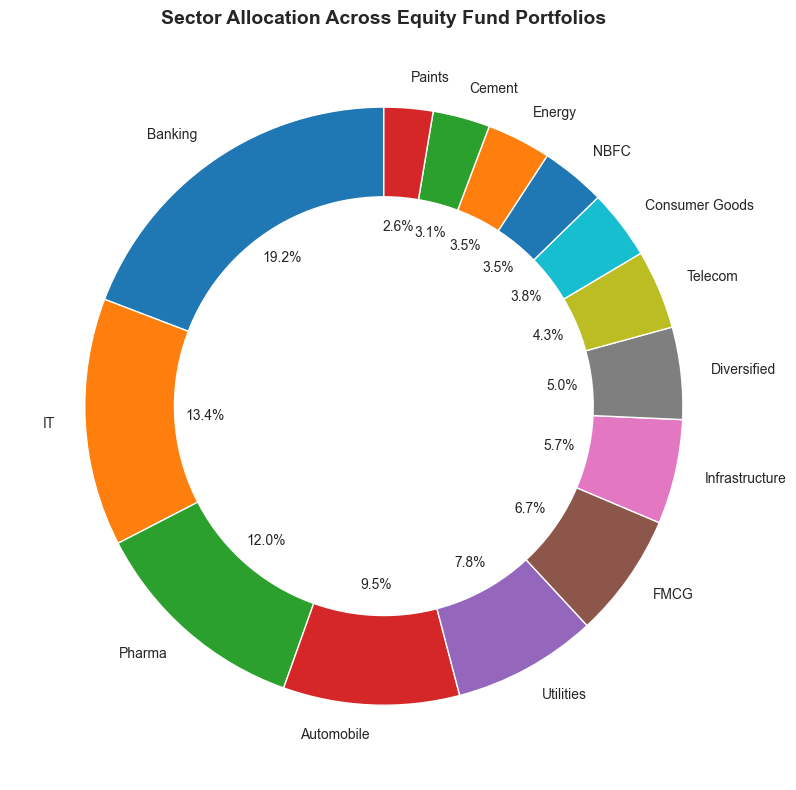

In [108]:
# =====================================================
# 9. TOP HOLDINGS SECTOR DISTRIBUTION
# =====================================================

sector_weights = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 8))

wedges, texts, autotexts = plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90
)

# Donut hole
centre_circle = plt.Circle(
    (0, 0),
    0.70,
    fc="white"
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title(
    "Sector Allocation Across Equity Fund Portfolios",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/09_sector_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/var/folders/f7/_gxg7ls978sccd0fgbz58h_80000gn/T/ipykernel_43145/2360614527.py:30: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/f7/_gxg7ls978sccd0fgbz58h_80000gn/T/ipykernel_43145/2360614527.py:32: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


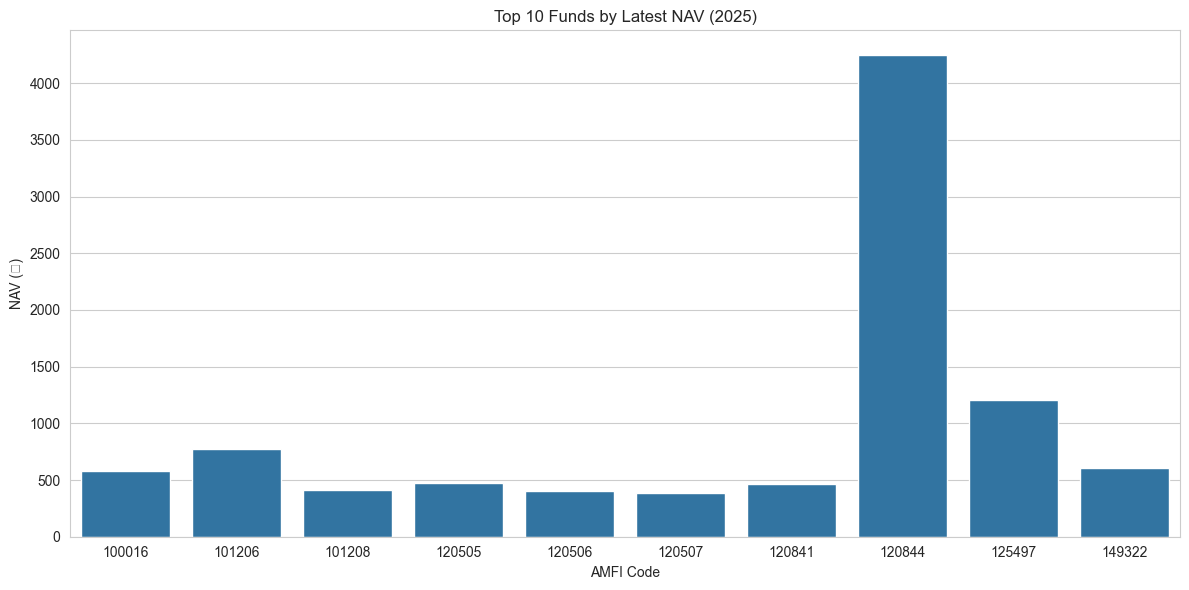

In [109]:
# =====================================================
# 10. TOP 10 FUNDS BY LATEST NAV
# =====================================================

latest_nav = (
    nav_history
    .sort_values("date")
    .groupby("amfi_code")
    .tail(1)
)

top_10_nav = (
    latest_nav
    .sort_values("nav", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_10_nav,
    x="amfi_code",
    y="nav"
)

plt.title("Top 10 Funds by Latest NAV (2025)")
plt.xlabel("AMFI Code")
plt.ylabel("NAV (₹)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/10_top_funds_latest_nav.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

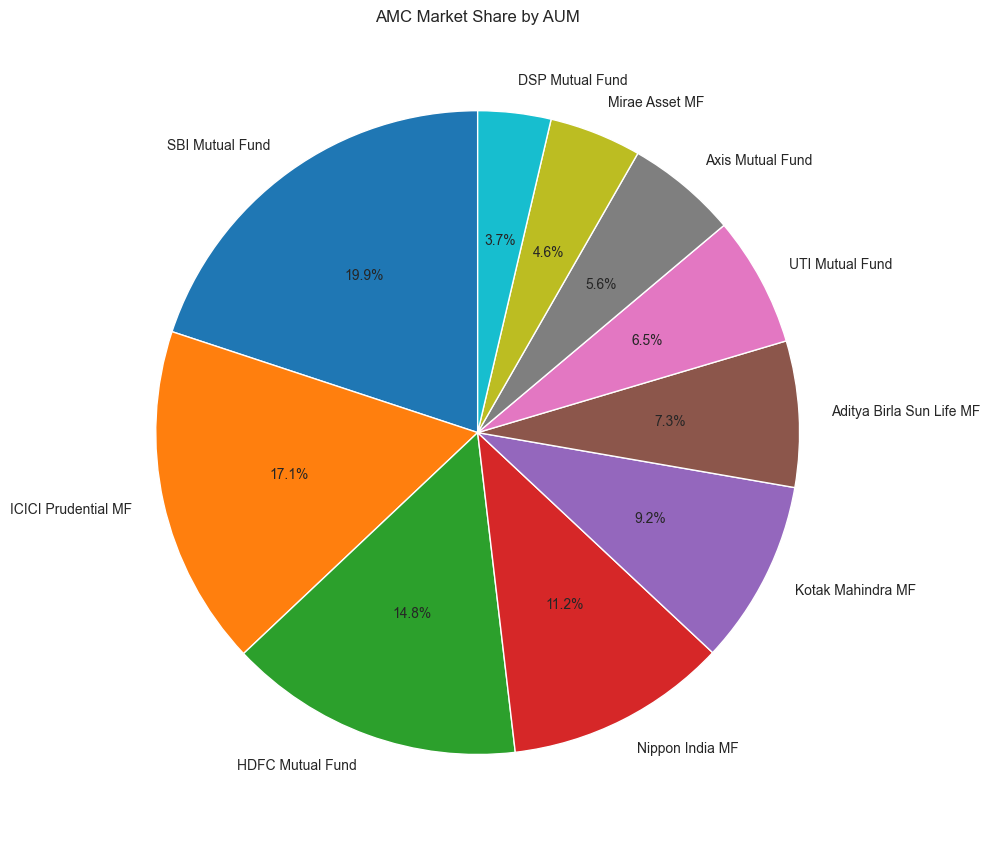

In [110]:
# =====================================================
# 11. AMC MARKET SHARE
# =====================================================

latest_aum = (
    aum.sort_values("date")
       .groupby("fund_house")
       .tail(1)
)

latest_aum = latest_aum.sort_values(
    "aum_crore",
    ascending=False
)

plt.figure(figsize=(10,10))

plt.pie(
    latest_aum["aum_crore"],
    labels=latest_aum["fund_house"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("AMC Market Share by AUM")

plt.tight_layout()

plt.savefig(
    "../reports/charts/11_amc_market_share.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

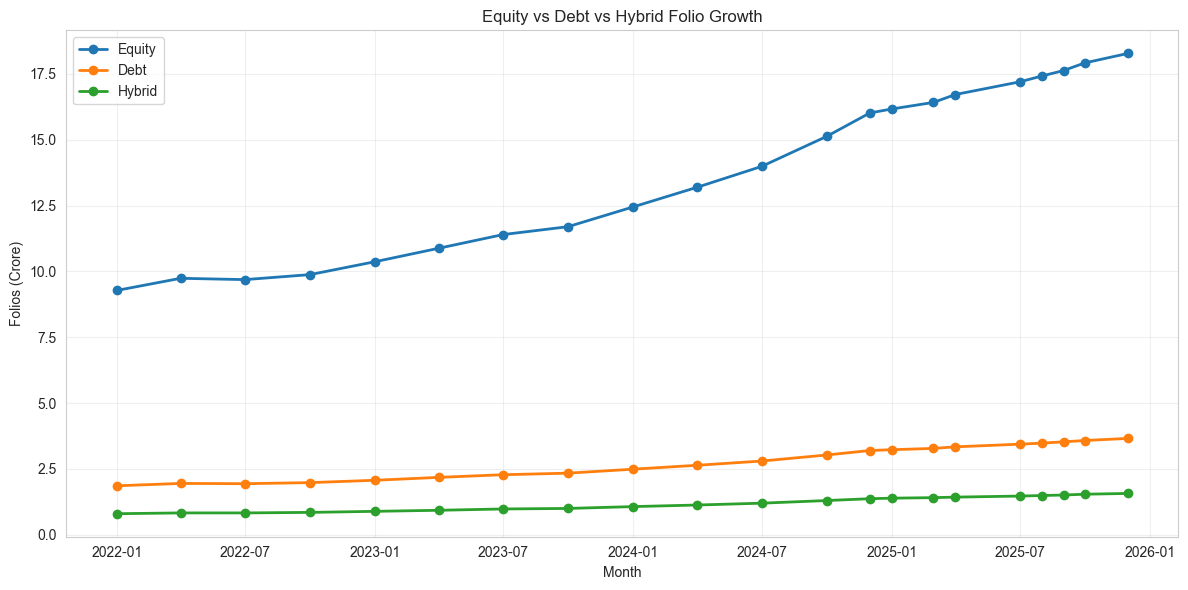

In [111]:
# =====================================================
# 12. FOLIO CATEGORY GROWTH
# =====================================================

plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["equity_folios_crore"],
    marker="o",
    linewidth=2,
    label="Equity"
)

plt.plot(
    folios["month"],
    folios["debt_folios_crore"],
    marker="o",
    linewidth=2,
    label="Debt"
)

plt.plot(
    folios["month"],
    folios["hybrid_folios_crore"],
    marker="o",
    linewidth=2,
    label="Hybrid"
)

plt.title("Equity vs Debt vs Hybrid Folio Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../reports/charts/12_folio_category_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

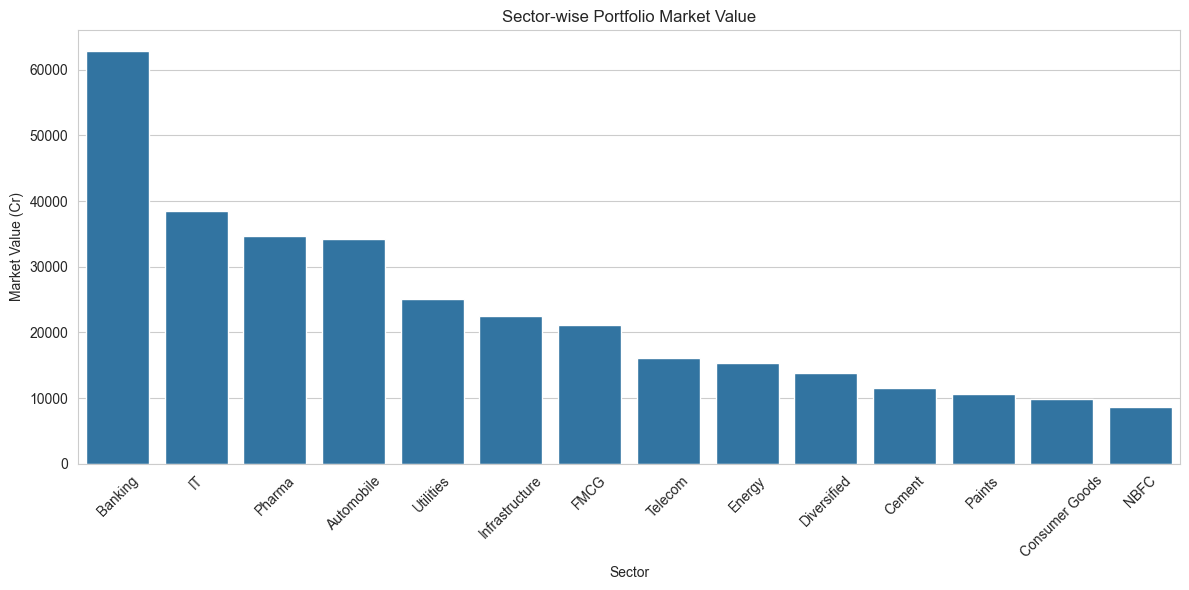

In [112]:
# =====================================================
# 13. SECTOR MARKET VALUE
# =====================================================

sector_value = (
    holdings.groupby("sector")["market_value_cr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=sector_value.index,
    y=sector_value.values
)

plt.title("Sector-wise Portfolio Market Value")
plt.xlabel("Sector")
plt.ylabel("Market Value (Cr)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/charts/13_sector_market_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

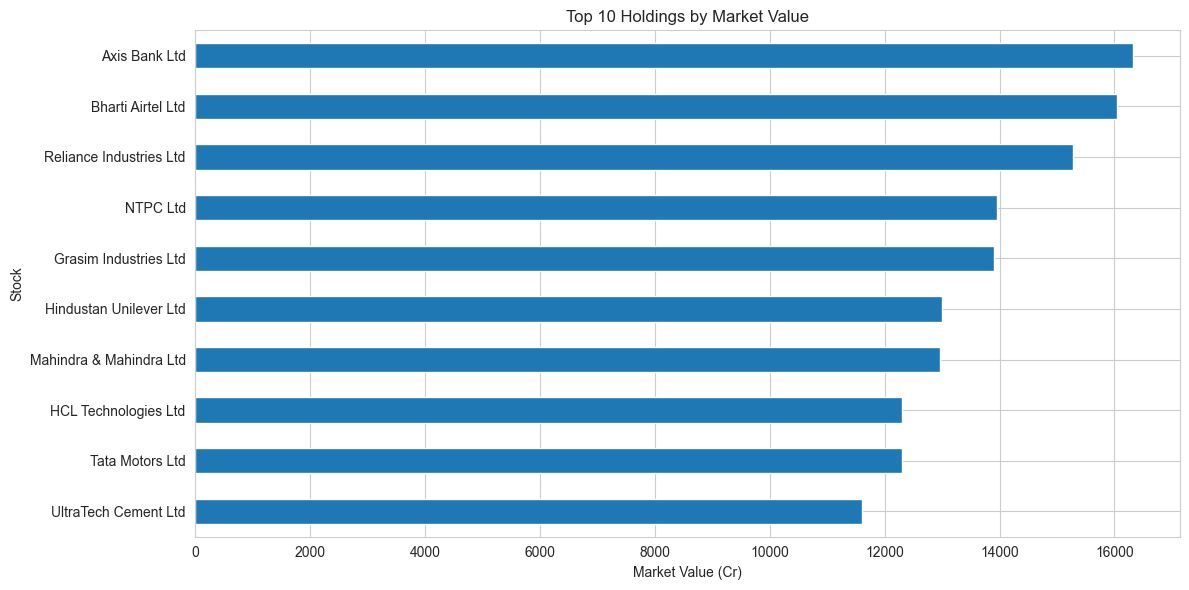

In [113]:
# =====================================================
# 14. TOP HOLDINGS
# =====================================================

top_holdings = (
    holdings.groupby("stock_name")["market_value_cr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_holdings.plot(
    kind="barh"
)

plt.title("Top 10 Holdings by Market Value")
plt.xlabel("Market Value (Cr)")
plt.ylabel("Stock")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../reports/charts/14_top_holdings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

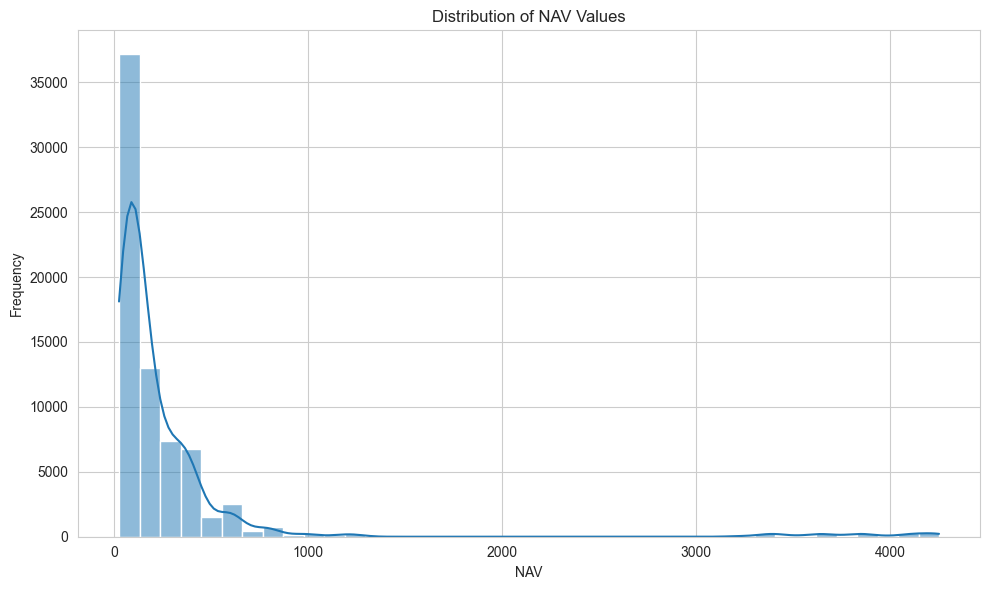

In [114]:
# =====================================================
# 15. NAV DISTRIBUTION
# =====================================================

plt.figure(figsize=(10,6))

sns.histplot(
    nav_history["nav"],
    bins=40,
    kde=True
)

plt.title("Distribution of NAV Values")
plt.xlabel("NAV")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../reports/charts/15_nav_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()